# Which states/regions/cities drive the most revenue?

### Methodology

- Aggregating the profit for each City
- Visualizing the data

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_excel('sample_superstore.xls')
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10189,10190,US-2026-143259,2026-12-30,2027-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,...,10009,East,OFF-BI-10003684,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,52.776,3,0.2,19.7910
10190,10191,US-2026-115427,2026-12-30,2027-01-03,Standard Class,EB-13975,Erica Bern,Corporate,United States,Fairfield,...,94533,West,OFF-BI-10004632,Office Supplies,Binders,GBC Binding covers,20.720,2,0.2,6.4750
10191,10192,US-2026-156720,2026-12-30,2027-01-03,Standard Class,JM-15580,Jill Matthias,Consumer,United States,Loveland,...,80538,West,OFF-FA-10003472,Office Supplies,Fasteners,Bagged Rubber Bands,3.024,3,0.2,-0.6048
10192,10193,US-2026-143259,2026-12-30,2027-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,...,10009,East,TEC-PH-10004774,Technology,Phones,Gear Head AU3700S Headset,90.930,7,0.0,2.7279


In [13]:
current_month = pd.Timestamp.today().month
df_filtered = df[
    (df['Order Date'].dt.year == 2026) &
    (df['Order Date'].dt.month <= current_month)
]
df_filtered

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
6815,6816,US-2026-151750,2026-01-01,2026-01-05,Standard Class,JM-15250,Janet Martin,Consumer,United States,Huntsville,...,77340,Central,FUR-CH-10003199,Furniture,Chairs,Office Star - Contemporary Task Swivel Chair,310.744,4,0.3,-26.6352
6816,6817,US-2026-144463,2026-01-01,2026-01-05,Standard Class,SC-20725,Steven Cartwright,Consumer,United States,Los Angeles,...,90036,West,FUR-FU-10001215,Furniture,Furnishings,"Howard Miller 11-1/2"" Diameter Brentwood Wall ...",474.430,11,0.0,199.2606
6817,6818,US-2026-151750,2026-01-01,2026-01-05,Standard Class,JM-15250,Janet Martin,Consumer,United States,Huntsville,...,77340,Central,FUR-FU-10002116,Furniture,Furnishings,"Tenex Carpeted, Granite-Look or Clear Contempo...",141.420,5,0.6,-187.3815
6818,6819,US-2026-107503,2026-01-01,2026-01-06,Standard Class,GA-14725,Guy Armstrong,Consumer,United States,Lorain,...,44052,East,FUR-FU-10003878,Furniture,Furnishings,"Linden 10"" Round Wall Clock, Black",48.896,4,0.2,8.5568
6819,6820,US-2026-151750,2026-01-01,2026-01-05,Standard Class,JM-15250,Janet Martin,Consumer,United States,Huntsville,...,77340,Central,OFF-AP-10004708,Office Supplies,Appliances,Fellowes Superior 10 Outlet Split Surge Protector,15.224,2,0.8,-38.8212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8938,8939,US-2026-120908,2026-09-30,2026-10-02,First Class,BF-10975,Barbara Fisher,Corporate,United States,Philadelphia,...,19120,East,OFF-LA-10004677,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters w...,20.664,7,0.2,6.9741
8939,8940,US-2026-144225,2026-09-30,2026-10-02,Second Class,CC-12475,Cindy Chapman,Consumer,United States,Baltimore,...,21215,East,OFF-PA-10000062,Office Supplies,Paper,Green Bar Computer Printout Paper,164.880,3,0.0,80.7912
8940,8941,US-2026-147452,2026-09-30,2026-10-03,First Class,CS-11845,Cari Sayre,Corporate,United States,Seattle,...,98103,West,OFF-PA-10001838,Office Supplies,Paper,Adams Telephone Message Book W/Dividers/Space ...,11.760,2,0.0,5.7624
8941,8942,US-2026-147452,2026-09-30,2026-10-03,First Class,CS-11845,Cari Sayre,Corporate,United States,Seattle,...,98103,West,OFF-PA-10004039,Office Supplies,Paper,Xerox 1882,167.940,3,0.0,82.2906


In [14]:
df_cities = df_filtered.groupby('City')['Profit'].sum().sort_values(ascending=False)
df_cities = df_cities.to_frame()
df_cities = df_cities.head(6)
df_cities

,Profit
City,
Seattle,14002.5479
New York City,9011.2280
Los Angeles,7572.8203
Jackson,4435.5688
San Francisco,3881.0559
Columbus,3219.8499


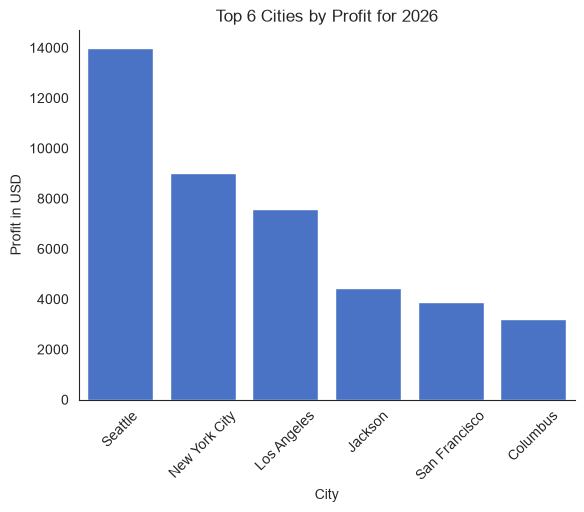

In [18]:
sns.barplot(data=df_cities, x='City', y='Profit')
sns.despine()
sns.set_style('white')
plt.xticks(rotation=45)
plt.title('Top 6 Cities by Profit for 2026')
plt.xlabel('City')
plt.ylabel('Profit in USD')
plt.show()